# Tokenization and BIO Tagging

In [ ]:
import json
import re
import random
import numpy as np
import tensorflow as tf
from collections import Counter
import matplotlib.pyplot as plt

## Load Data

In [6]:
# load the offset-corrected dataset produced in 01_eda.ipynb
with open('../data/dataset_fixed.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

samples = raw["data"] if isinstance(raw, dict) and "data" in raw else raw

print(f"loaded {len(samples)} samples.")
print(f"first sample text:\n{samples[0]['text']}")
print(f"first sample entities:\n{samples[0]['entities']}")

loaded 13226 samples.
first sample text:
Mohon kesediaannya untuk melunasi tagihan kopi kemarin. Saya lampirkan rinciannya, termasuk biaya surge karena hujan yang cukup mengagetkan.
- Rensy: kripik cireng toples (49 K)
- Lainnya: carbonara truffle (148 K)
Silakan ditransfer, x9.
first sample entities:
[{'start': 143, 'end': 148, 'label': 'PERSON', 'text': 'Rensy'}, {'start': 150, 'end': 170, 'label': 'ITEM', 'text': 'kripik cireng toples'}, {'start': 172, 'end': 176, 'label': 'PRICE', 'text': '49 K'}, {'start': 189, 'end': 206, 'label': 'ITEM', 'text': 'carbonara truffle'}, {'start': 208, 'end': 213, 'label': 'PRICE', 'text': '148 K'}, {'start': 235, 'end': 237, 'label': 'MULTIPLIER', 'text': 'x9'}]


## Tokenization

In [18]:
# compile regex pattern
# matches words, numbers, and things joined by dots/commas/hyphens (e.g. Rp45.000, 335k-an)
# or matches any single character that is not a word char or whitespace (e.g. ~, ±, (, ))
TOKEN_PAT = re.compile(r'[a-zA-Z0-9]+(?:[-.,][a-zA-Z0-9]+)*|[^\w\s]')

def tokenize_with_spans(text): # takes a raw string
    tokens = []
    for match in TOKEN_PAT.finditer(text):
        tokens.append((match.group(), match.start(), match.end()))
    return tokens # returns list of tuples (token_text, start_idx, end_idx)

# test the tokenizer on first sample
sample_text = samples[0]['text']
tokens = tokenize_with_spans(sample_text)

print("tokenization result:")
for t in tokens:
    print(t)

tokenization result:
('Mohon', 0, 5)
('kesediaannya', 6, 18)
('untuk', 19, 24)
('melunasi', 25, 33)
('tagihan', 34, 41)
('kopi', 42, 46)
('kemarin', 47, 54)
('.', 54, 55)
('Saya', 56, 60)
('lampirkan', 61, 70)
('rinciannya', 71, 81)
(',', 81, 82)
('termasuk', 83, 91)
('biaya', 92, 97)
('surge', 98, 103)
('karena', 104, 110)
('hujan', 111, 116)
('yang', 117, 121)
('cukup', 122, 127)
('mengagetkan', 128, 139)
('.', 139, 140)
('-', 141, 142)
('Rensy', 143, 148)
(':', 148, 149)
('kripik', 150, 156)
('cireng', 157, 163)
('toples', 164, 170)
('(', 171, 172)
('49', 172, 174)
('K', 175, 176)
(')', 176, 177)
('-', 178, 179)
('Lainnya', 180, 187)
(':', 187, 188)
('carbonara', 189, 198)
('truffle', 199, 206)
('(', 207, 208)
('148', 208, 211)
('K', 212, 213)
(')', 213, 214)
('Silakan', 215, 222)
('ditransfer', 223, 233)
(',', 233, 234)
('x9', 235, 237)
('.', 237, 238)


## Span to BIO Conversion

In [8]:
# this function aligns token spans with entity spans to generate BIO tags.
# receive: tokens: list of (text, start, end), entities: list of dicts with 'start', 'end', 'label'
def align_spans_to_bio(tokens, entities):
    # initialize all tags to outside
    tags = ['O'] * len(tokens)
    
    # iterate over each entity and find overlapping tokens
    for ent in entities:
        e_start = ent['start']
        e_end = ent['end']
        e_label = ent['label']
        
        first_token_found = False
        
        for i, (tok_text, t_start, t_end) in enumerate(tokens):
            # check for overlap: token starts before entity ends AND token ends after entity starts
            if t_start < e_end and t_end > e_start:
                if not first_token_found:
                    tags[i] = f"B-{e_label}"
                    first_token_found = True
                else:
                    tags[i] = f"I-{e_label}"
                    
    return tags

# test the aligner on the first sample
sample_entities = samples[0]['entities']
sample_tags = align_spans_to_bio(tokens, sample_entities)

print("bio alignment check:")
for (tok_text, _, _), tag in zip(tokens[30:55], sample_tags[30:55]):
    print(f"{tok_text:<20} {tag}")

bio alignment check:
)                    O
-                    O
Lainnya              O
:                    O
carbonara            B-ITEM
truffle              I-ITEM
(                    O
148                  B-PRICE
K                    I-PRICE
)                    O
Silakan              O
ditransfer           O
,                    O
x9                   B-MULTIPLIER
.                    O


## Test on Entire Dataset

In [19]:
processed_dataset = []
drop_count = 0

for i, sample in enumerate(samples):
    text = sample['text']
    entities = sample.get('entities', [])
    
    # skip empty samples
    if not text.strip():
        drop_count += 1
        continue
        
    try:
        tokens_with_spans = tokenize_with_spans(text)
        
        # strip the spans out for the final dataset, keep only the text tokens
        just_tokens = [t[0] for t in tokens_with_spans]
        tags = align_spans_to_bio(tokens_with_spans, entities)
        
        # token list and tag list must be identical in length
        assert len(just_tokens) == len(tags)
        
        processed_dataset.append({
            'tokens': just_tokens,
            'tags': tags
        })
        
    except Exception as e:
        print(f"error processing sample {i}: {e}")
        drop_count += 1

print(f"processed {len(processed_dataset)} samples successfully.")
print(f"dropped {drop_count} samples.")

# display the final format for model consumption
print("\nexample output:")
print("tokens:", processed_dataset[0]['tokens'][30:45])
print("tags:  ", processed_dataset[0]['tags'][30:45])

processed 13226 samples successfully.
dropped 0 samples.

example output:
tokens: [')', '-', 'Lainnya', ':', 'carbonara', 'truffle', '(', '148', 'K', ')', 'Silakan', 'ditransfer', ',', 'x9', '.']
tags:   ['O', 'O', 'O', 'O', 'B-ITEM', 'I-ITEM', 'O', 'B-PRICE', 'I-PRICE', 'O', 'O', 'O', 'O', 'B-MULTIPLIER', 'O']


## Statistical Validation

In [10]:
# sequence length analysis
seq_lengths = [len(sample['tokens']) for sample in processed_dataset]

print("sequence length stats")
print(f"max length:  {max(seq_lengths)}")
print(f"min length:  {min(seq_lengths)}")
print(f"mean length: {sum(seq_lengths) / len(seq_lengths):.2f}")

# tag distribution analysis
all_tags = [tag for sample in processed_dataset for tag in sample['tags']]
tag_counts = Counter(all_tags)

print("\ntag distribution")
for tag, count in tag_counts.most_common():
    print(f"{tag:<15} {count}")

# 3. simple sanity check on label transitions
# e.g., making sure I-ITEM only follows B-ITEM or I-ITEM
invalid_transitions = 0
for sample in processed_dataset:
    tags = sample['tags']
    for i in range(1, len(tags)):
        if tags[i].startswith('I-'):
            expected_base = tags[i][2:]
            prev_tag = tags[i-1]
            if not (prev_tag == f'B-{expected_base}' or prev_tag == f'I-{expected_base}'):
                invalid_transitions += 1

print(f"\n--- transition check ---")
print(f"invalid BIO transitions found: {invalid_transitions}")
assert invalid_transitions == 0, "found broken BIO logic!"

--- sequence length stats ---
max length:  166
min length:  1
mean length: 44.86

--- tag distribution ---
O               427139
B-PRICE         35973
B-PERSON        34891
I-ITEM          30470
I-PRICE         26928
B-ITEM          21697
B-MULTIPLIER    10824
I-MULTIPLIER    5417

--- transition check ---
invalid BIO transitions found: 0


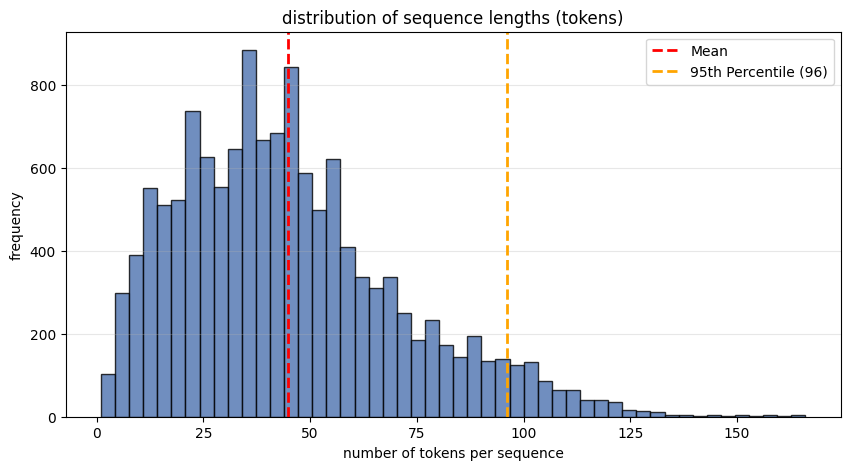

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(seq_lengths, bins=50, color='#4C72B0', edgecolor='black', alpha=0.8)
plt.axvline(sum(seq_lengths)/len(seq_lengths), color='red', linestyle='dashed', linewidth=2, label='Mean')

pct_95 = int(np.percentile(seq_lengths, 95))
plt.axvline(pct_95, color='orange', linestyle='dashed', linewidth=2, label=f'95th Percentile ({pct_95})')

plt.title('distribution of sequence lengths (tokens)')
plt.xlabel('number of tokens per sequence')
plt.ylabel('frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [24]:
%%writefile ../src/preprocessing/tokenizer.py
import re
import tensorflow as tf

class BillTokenizer:
    def __init__(self):
        # matches words, numbers with punctuation, and stray symbols
        self.token_pat = re.compile(r'[a-zA-Z0-9]+(?:[-.,][a-zA-Z0-9]+)*|[^\w\s]')
        
        # placeholders for vocabulary building
        self.word2idx = {}
        self.char2idx = {}
        self.tag2idx = {}
        
    def _tokenize_spans(self, text):
        """method to get tokens + spans"""
        return [(m.group(), m.start(), m.end()) for m in self.token_pat.finditer(text)]

    def extract_tokens(self, text):
        """pure text tokenization"""
        # handle tf.string tensors if mapped via tf.data
        if isinstance(text, tf.Tensor):
            text = text.numpy().decode('utf-8')
        return [m.group() for m in self.token_pat.finditer(text)]

    def align_bio(self, text, entities):
        """aligns text and entity dictionaries into token/tag lists"""
        # handle tf.string tensors
        if isinstance(text, tf.Tensor):
            text = text.numpy().decode('utf-8')
            
        spans = self._tokenize_spans(text)
        tokens = [s[0] for s in spans]
        tags = ['O'] * len(spans)
        
        for ent in entities:
            e_start, e_end, e_label = ent['start'], ent['end'], ent['label']
            first = False
            for i, (_, t_start, t_end) in enumerate(spans):
                if t_start < e_end and t_end > e_start:
                    if not first:
                        tags[i] = f"B-{e_label}"
                        first = True
                    else:
                        tags[i] = f"I-{e_label}"
                        
        return tokens, tags

Overwriting ../src/preprocessing/tokenizer.py


## Dataset Splitting

In [25]:
random.seed(42)
random.shuffle(processed_dataset)

total_samples = len(processed_dataset)
train_end = int(total_samples * 0.8)
val_end = int(total_samples * 0.9)

train_data = processed_dataset[:train_end]
val_data = processed_dataset[train_end:val_end]
test_data = processed_dataset[val_end:]

print(f"train: {len(train_data)}, val: {len(val_data)}, test: {len(test_data)}")

train: 10580, val: 1323, test: 1323


## Building Vocabulary

In [26]:
# build vocab strictly on the training set to prevent data leakage.
MIN_WORD_FREQ = 2 # standard threshold to push rare words to UNK

word_counts = Counter(word for sample in train_data for word in sample['tokens'])
char_counts = Counter(char for sample in train_data for word in sample['tokens'] for char in word)
tag_counts  = Counter(tag for sample in train_data for tag in sample['tags'])

# reserve index 0 for padding, 1 for unknown
word2idx = {"[PAD]": 0, "[UNK]": 1}
char2idx = {"[PAD]": 0, "[UNK]": 1}
tag2idx  = {"[PAD]": 0} # tags don't strictly need UNK if our universe is closed, but need PAD

for word, freq in word_counts.items():
    if freq >= MIN_WORD_FREQ:
        word2idx[word] = len(word2idx)
        
for char, _ in char_counts.items():
    char2idx[char] = len(char2idx)

for tag, _ in tag_counts.items():
    tag2idx[tag] = len(tag2idx)

idx2tag = {i: t for t, i in tag2idx.items()}

print(f"word vocab size: {len(word2idx)}")
print(f"char vocab size: {len(char2idx)}")
print(f"tag vocab size:  {len(tag2idx)}")

word vocab size: 14669
char vocab size: 118
tag vocab size:  9


## tf.Data Pipeline

In [15]:
MAX_LEN = 100
MAX_WORD_LEN = 15

def vectorize_dataset(data, word2idx, char2idx, tag2idx, max_len, max_word_len):
    # pre-allocate numpy arrays for speed
    num_samples = len(data)
    X_word = np.zeros((num_samples, max_len), dtype=np.int32)
    X_char = np.zeros((num_samples, max_len, max_word_len), dtype=np.int32)
    Y      = np.zeros((num_samples, max_len), dtype=np.int32)
    
    for i, sample in enumerate(data):
        tokens = sample['tokens'][:max_len]
        tags = sample['tags'][:max_len]
        
        for j, (word, tag) in enumerate(zip(tokens, tags)):
            X_word[i, j] = word2idx.get(word, word2idx["[UNK]"])
            Y[i, j] = tag2idx.get(tag, tag2idx["[PAD]"])
            
            # char level padding and truncation
            chars = list(word)[:max_word_len]
            for k, char in enumerate(chars):
                X_char[i, j, k] = char2idx.get(char, char2idx["[UNK]"])
                
    return X_word, X_char, Y

# map to integers
X_word_train, X_char_train, Y_train = vectorize_dataset(train_data, word2idx, char2idx, tag2idx, MAX_LEN, MAX_WORD_LEN)
X_word_val, X_char_val, Y_val       = vectorize_dataset(val_data, word2idx, char2idx, tag2idx, MAX_LEN, MAX_WORD_LEN)
X_word_test, X_char_test, Y_test    = vectorize_dataset(test_data, word2idx, char2idx, tag2idx, MAX_LEN, MAX_WORD_LEN)

# build standard tf datasets
BATCH_SIZE = 32

def create_tf_dataset(X_w, X_c, Y, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(({'word_inputs': X_w, 'char_inputs': X_c}, Y))
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = create_tf_dataset(X_word_train, X_char_train, Y_train, BATCH_SIZE, shuffle=True)
val_ds   = create_tf_dataset(X_word_val, X_char_val, Y_val, BATCH_SIZE)
test_ds  = create_tf_dataset(X_word_test, X_char_test, Y_test, BATCH_SIZE)

# check shapes
for inputs, labels in train_ds.take(1):
    print("word inputs shape:", inputs['word_inputs'].shape)
    print("char inputs shape:", inputs['char_inputs'].shape)
    print("labels shape:     ", labels.shape)

word inputs shape: (32, 100)
char inputs shape: (32, 100, 15)
labels shape:      (32, 100)


## Modularize DatasetBuilder

In [28]:
%%writefile ../src/preprocessing/preprocess.py
import os
import json
import random
import numpy as np
import tensorflow as tf
from collections import Counter
from tqdm import tqdm
from .tokenizer import BillTokenizer

class DatasetBuilder:
    def __init__(self, 
                 max_len=100, 
                 max_word_len=15, 
                 min_word_freq=2, 
                 train_pct=0.8, 
                 val_pct=0.1, 
                 seed=42,
                 verbose=True):
        
        # padding and truncation knobs
        self.max_len = max_len
        self.max_word_len = max_word_len
        self.min_word_freq = min_word_freq
        
        # splitting knobs (test_pct is implicitly the remainder)
        self.train_pct = train_pct
        self.val_pct = val_pct
        
        self.seed = seed
        self.verbose = verbose
        self.tokenizer = BillTokenizer()
        
        # initialize vocabularies
        self.word2idx = {"[PAD]": 0, "[UNK]": 1}
        self.char2idx = {"[PAD]": 0, "[UNK]": 1}
        self.tag2idx  = {"[PAD]": 0}
        
    def build_from_file(self, filepath, batch_size=32):
        # load raw data
        with open(filepath, 'r', encoding='utf-8') as f:
            raw = json.load(f)
        samples = raw["data"] if isinstance(raw, dict) and "data" in raw else raw
        
        # apply tokenizer.align_bio()
        processed_dataset = []
        
        # use tqdm if verbose is on
        iterator = tqdm(samples, desc="aligning BIO tags") if self.verbose else samples
        
        for sample in iterator:
            text = sample.get('text', '')
            entities = sample.get('entities', [])
            
            if not text.strip():
                continue
                
            try:
                tokens, tags = self.tokenizer.align_bio(text, entities)
                if len(tokens) == len(tags):
                    processed_dataset.append({
                        'tokens': tokens,
                        'tags': tags
                    })
            except Exception as e:
                if self.verbose:
                    print(f"skipping sample due to error: {e}")
                
        # train/val/test split
        random.seed(self.seed)
        random.shuffle(processed_dataset)
        
        total_samples = len(processed_dataset)
        train_end = int(total_samples * self.train_pct)
        val_end = train_end + int(total_samples * self.val_pct)
        
        train_data = processed_dataset[:train_end]
        val_data = processed_dataset[train_end:val_end]
        test_data = processed_dataset[val_end:]
        
        if self.verbose:
            print(f"split totals -> train: {len(train_data)}, val: {len(val_data)}, test: {len(test_data)}")
        
        # build vocab strictly on train data
        word_counts = Counter(word for sample in train_data for word in sample['tokens'])
        char_counts = Counter(char for sample in train_data for word in sample['tokens'] for char in word)
        tag_counts  = Counter(tag for sample in train_data for tag in sample['tags'])
        
        for word, freq in word_counts.items():
            if freq >= self.min_word_freq:
                self.word2idx[word] = len(self.word2idx)
                
        for char, _ in char_counts.items():
            self.char2idx[char] = len(self.char2idx)

        for tag, _ in tag_counts.items():
            self.tag2idx[tag] = len(self.tag2idx)
            
        if self.verbose:
            print(f"vocab sizes -> word: {len(self.word2idx)}, char: {len(self.char2idx)}, tag: {len(self.tag2idx)}")
            
        # internal vectorizer function
        def _vectorize(data, desc):
            num_samples = len(data)
            X_w = np.zeros((num_samples, self.max_len), dtype=np.int32)
            X_c = np.zeros((num_samples, self.max_len, self.max_word_len), dtype=np.int32)
            Y   = np.zeros((num_samples, self.max_len), dtype=np.int32)
            
            data_iterator = tqdm(data, desc=f"vectorizing {desc}", leave=False) if self.verbose else data
            
            for i, sample in enumerate(data_iterator):
                for j, (word, tag) in enumerate(zip(sample['tokens'][:self.max_len], sample['tags'][:self.max_len])):
                    X_w[i, j] = self.word2idx.get(word, self.word2idx["[UNK]"])
                    Y[i, j] = self.tag2idx.get(tag, self.tag2idx["[PAD]"])
                    
                    for k, char in enumerate(list(word)[:self.max_word_len]):
                        X_c[i, j, k] = self.char2idx.get(char, self.char2idx["[UNK]"])
            return X_w, X_c, Y

        # vectorize splits
        X_w_tr, X_c_tr, Y_tr = _vectorize(train_data, "train")
        X_w_v, X_c_v, Y_v    = _vectorize(val_data, "val")
        X_w_te, X_c_te, Y_te = _vectorize(test_data, "test")
        
        # internal tf.data wrapper
        def _create_ds(X_w, X_c, Y, shuffle=False):
            ds = tf.data.Dataset.from_tensor_slices(({'word_inputs': X_w, 'char_inputs': X_c}, Y))
            if shuffle:
                ds = ds.shuffle(buffer_size=1000, seed=self.seed)
            return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

        # return final tf.data.Datasets
        train_ds = _create_ds(X_w_tr, X_c_tr, Y_tr, shuffle=True)
        val_ds   = _create_ds(X_w_v, X_c_v, Y_v)
        test_ds  = _create_ds(X_w_te, X_c_te, Y_te)
        
        return train_ds, val_ds, test_ds
        
    def save_vocabs(self, save_dir):
        """dumps the dicts to json for inference later"""
        os.makedirs(save_dir, exist_ok=True)
        
        with open(os.path.join(save_dir, 'word2idx.json'), 'w', encoding='utf-8') as f:
            json.dump(self.word2idx, f, ensure_ascii=False, indent=2)
            
        with open(os.path.join(save_dir, 'char2idx.json'), 'w', encoding='utf-8') as f:
            json.dump(self.char2idx, f, ensure_ascii=False, indent=2)
            
        with open(os.path.join(save_dir, 'tag2idx.json'), 'w', encoding='utf-8') as f:
            json.dump(self.tag2idx, f, ensure_ascii=False, indent=2)
            
        if self.verbose:
            print(f"saved vocabs to {save_dir}")

Overwriting ../src/preprocessing/preprocess.py


## Usage Example

```python
# usage example: how to plug this into the training pipeline
from src.preprocessing.preprocess import DatasetBuilder

# init the builder with our chosen hyperparameters
# keep max_len at 100 based 95th percentile analysis
builder = DatasetBuilder(
    max_len=100,
    max_word_len=15,
    min_word_freq=2,
    train_pct=0.8,
    val_pct=0.1,
    verbose=True
)

# build the tf.data pipelines directly from the raw json
# this handles alignment, splitting, and vectorization under the hood
data_path = '../data/dataset_fixed.json'
train_ds, val_ds, test_ds = builder.build_from_file(data_path, batch_size=32)

# save the vocabularies (used in inference later)
# we need these dicts to map new text -> ints, and output ints -> BIO tags
builder.save_vocabs('../models/vocabs/')

# sanity check before feeding to model.fit()
# let's rip one batch out of the training dataset to inspect shapes
for inputs, labels in train_ds.take(1):
    print("\n--- batch shapes ---")
    
    # should be (batch_size, max_len) -> (32, 100)
    # these feed into the word embedding layer
    print("word inputs: ", inputs['word_inputs'].shape)
    
    # should be (batch_size, max_len, max_word_len) -> (32, 100, 15)
    # these feed into the character-cnn layer
    print("char inputs: ", inputs['char_inputs'].shape)
    
    # should be (batch_size, max_len) -> (32, 100)
    # these are the BIO tag targets for the CRF layer
    print("labels:      ", labels.shape)
    
    break # just need one batch to verify
```